In [1]:
from atomic_units import AtomicUnitSystem, hartree_atomic_base_units

# Példa: Hartree Atomic Unit System
hau_system = AtomicUnitSystem(base_units=hartree_atomic_base_units)
print(hau_system.length_unit)
print(hau_system.energy_unit)

5.2917721090397754e-11 meter
4.35974472220717e-18 joule


In [2]:
import atomic_units as au
import pint
import numpy as np

hb=1.0
e0=1.0
m0=100.0
kappa0=1.0 # 4*pi*epsilon0
dx=0.025

print(1.0/(2*dx**2))
alpha_times_c = e0**2/(kappa0*hb)
print(alpha_times_c)
#print(e0**2/(kappa0*hb))

prefactor = hb**2/(2*m0*dx**2)
desired_prefactor = 0.5
prefactor_error = np.abs(prefactor-desired_prefactor)/desired_prefactor
print(f"Prefactor: {prefactor}")
print(f"Prefactor error: {prefactor_error}")

ureg = pint.UnitRegistry()

length_unit = ((kappa0 * hb ** 2 / (m0 * e0 ** 2))*ureg.bohr).to('nm')
step_unit = dx*length_unit
desired_step_unit = 0.1*ureg.nm
step_unit_error = (np.abs(step_unit-desired_step_unit)/desired_step_unit).magnitude
print(f"step unit in SI: {step_unit.to('nm')}")
print(f"step unit error: {step_unit_error}")

scaled_units_system = au.AtomicUnitSystem(xh=hb, xe=e0, xm=m0, xk=kappa0)

print(scaled_units_system)
print(scaled_units_system.mass_unit.to('kg'))

print(f"Length unit: {scaled_units_system.length_unit.to('nm')}")
print(f"Step unit: {dx*scaled_units_system.length_unit.to('nm')}")
print(f"Length unit in AU: {scaled_units_system.length_unit.to('bohr')}")


799.9999999999999
1.0
Prefactor: 7.999999999999998
Prefactor error: 14.999999999999996
step unit in SI: 1.3229430272599437e-05 nanometer
step unit error: 0.999867705697274
Value of atomic base units in this rescaled atomic units:
- modified planck constant hbar := 1.0
- elementary charge := 1.0
- electron mass := 100.0
- modified permittivity := 1.0

Derived units in this rescaled atomic unit system:
- length unit := 	5.291772109039775e-09 meter
- energy unit := 	4.35974472220717e-20 joule
- time unit := 	2.4188843265856802e-15 second
- frequency unit := 	413413733351824.5 hertz
- velocity unit := 	2187691.2636451917 meter / second
- speed of light := 	137.03599908356242
- electric field unit := 	51422067.47623178 volt / meter
- electric potential unit := 	0.2721138624598847 volt

9.1093837015e-33 kilogram
Length unit: 5.2917721090397745 nanometer
Step unit: 0.13229430272599438 nanometer
Length unit in AU: 99.99999999999999 bohr


# testing masking functions

0.20202020202020243


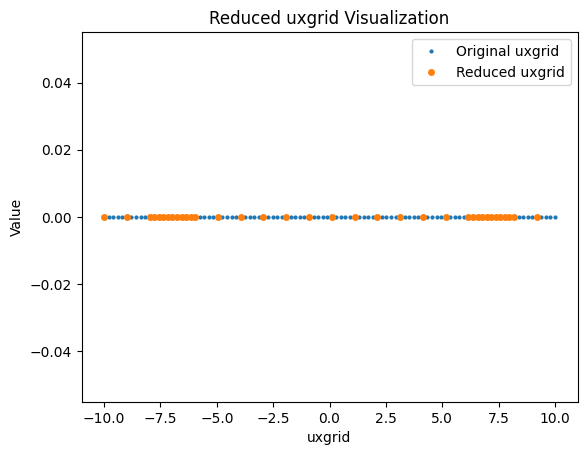

In [3]:
import numpy as np
import matplotlib.pyplot as plt

uxgrid_num = 100
uxgrid = np.linspace(-10, 10, uxgrid_num)
uxgrid_dx = uxgrid[1]-uxgrid[0]
print(uxgrid_dx)

# Desired number of points
desired_points = 20

# Calculate the step size to reduce the number of points
step_size = uxgrid_num // desired_points

# Create the mask
mask = np.zeros(uxgrid_num, dtype=bool)
mask[::step_size] = True

# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Highlighted ranges
highlight_ranges = [(-8, -6), (6, 8)]

# Initialize mask
mask_highlight_ranges = np.zeros(uxgrid_num, dtype=bool)

# Apply mask for highlighted ranges
for start, end in highlight_ranges:
    mask_highlight_ranges |= (uxgrid >= start) & (uxgrid <= end)

# Number of highlighted points
highlighted_num = np.sum(mask_highlight_ranges)

mask += mask_highlight_ranges

# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=2, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=4, label='Reduced uxgrid')
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

In [4]:
t_start=0
t_stop=12.0
utgrid_dt=0.1
utgrid=np.arange(t_start,t_stop,utgrid_dt)

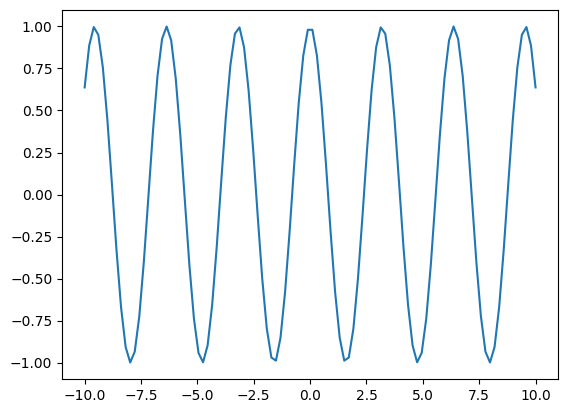

In [5]:
import quantum_toolkit as quat

k_pw = 2

dispersion=quat.Dispersion(uxgrid_dx)

wave_function = quat.plane_wave(dispersion.k2omega(k_pw), uxgrid)

plt.plot(uxgrid, np.real(wave_function['value']))


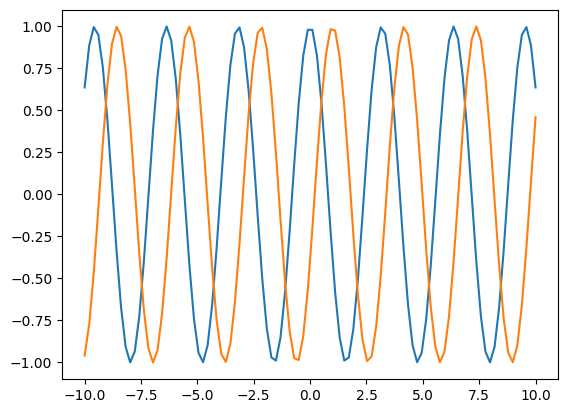

In [6]:
te_wave_function = quat.stationary_time_evolution(dispersion.k2omega(k_pw), utgrid, wave_function)

plt.plot(uxgrid, np.real(te_wave_function['value'][:,0]))
plt.plot(uxgrid, np.real(te_wave_function['value'][:,10])) 

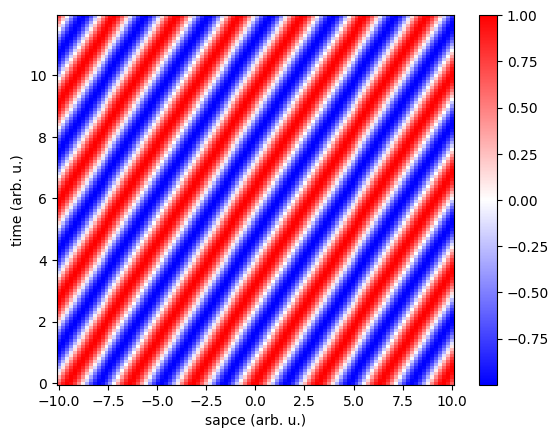

In [7]:
X,Y = np.meshgrid(uxgrid,utgrid)

Z=np.transpose(np.real(te_wave_function['value']))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
#plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
#plt.ylim(0,2*laserpot_cep0.temporal_width)
plt.show()

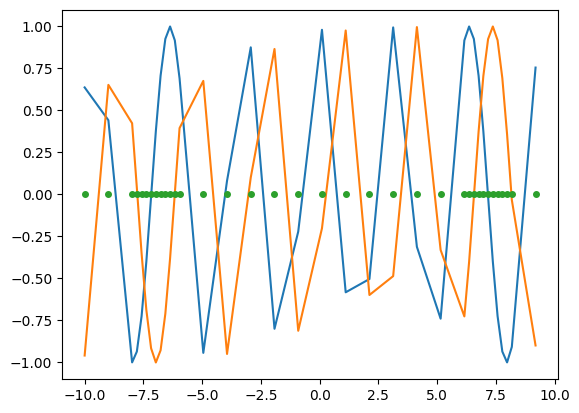

In [8]:
reduced_te_wave_function = quat.stationary_time_evolution(dispersion.k2omega(k_pw), utgrid, wave_function, mask)

plt.plot(reduced_uxgrid, np.real(reduced_te_wave_function['value'][:,0]))
plt.plot(reduced_uxgrid, np.real(reduced_te_wave_function['value'][:,10])) 
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=4, label='Reduced uxgrid')
plt.show()

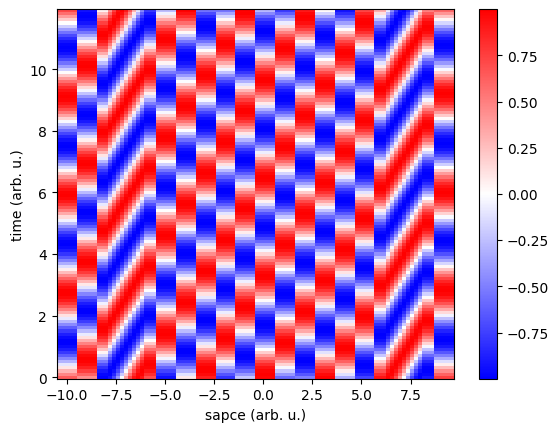

In [9]:
X,Y = np.meshgrid(reduced_uxgrid,utgrid)

Z=np.transpose(np.real(reduced_te_wave_function['value']))
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') 
plt.colorbar(pcm)
 
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.show()

# Set Atomic unit system

In [10]:
from scipy.optimize import minimize
import atomic_units as au
from atomic_units import hartree_atomic_unit_system as haus

dx=0.025
emax=6 # Maximum electron energy in eV

print(emax*haus.ureg("eV"),haus.energy_unit.to("eV"))

def objective_function(x):

    #xhb=1
    xe=1
    hb, m0, k0 = x
    usys = au.AtomicUnitSystem(xh=hb, xe=xe, xm=m0, xk=k0)

    emax_in_usys = (emax*usys.ureg("eV")/usys.energy_unit.to("eV")).magnitude

    # Calculate the prefactor
    ct=quat.const_t(dx,hb,m0)

    delta_e=abs(emax_in_usys-ct)
    delta_length=abs((dx*usys.length_unit.to("nm")-0.1*usys.ureg("nm")).magnitude)
    print(m0,k0,emax_in_usys,usys.energy_unit.to("eV"),delta_e)

    return delta_e**2 + delta_length**2

result = minimize(objective_function, [50,50,1], bounds=((1, 100),(1,100),(1,100) ), method='L-BFGS-B')
print(result.x)  # Optimal solution
print(result.fun)  # Objective function value at the optimal solution

# >>> [-1.07505143e-08 -1.07505143e-08]

6 electron_volt 27.21138624598847 electron_volt
50.0 1.0 0.004409918661078522 1360.5693122994235 electron_volt 39999.99559008133
50.0 1.0 0.004409918659314554 1360.5693128436517 electron_volt 39999.995606081335
50.00000001 1.0 0.004409918661960506 1360.5693120273097 electron_volt 39999.99558208133
50.0 1.00000001 0.004409918572880152 1360.5693395108096 electron_volt 39999.99559008142
100.0 1.0 22.049593305392612 0.2721138624598847 electron_volt 14.049593305392614
100.0 1.0 22.049592864400754 0.27211386790216197 electron_volt 14.049592704400757
99.99999999 1.0 22.049593303187656 0.27211386248709607 electron_volt 14.049593302387658
100.0 1.00000001 22.049592864400754 0.27211386790216197 electron_volt 14.049592864400756
99.99990698972228 1.0005730964168165 21.99777298540277 0.2727548831411919 electron_volt 13.988110573317968
99.99990698972228 1.0005730964168165 21.99777254571256 0.27275488859300073 electron_volt 13.988109973531092
99.99990699972227 1.0005730964168165 21.997772987602538 0.

In [11]:
import atomic_units as au

hb=1.0
e0=1.0
m0=100.0
kappa0=1.0 # 4*pi*epsilon0
dx=0.025

unit_sys = au.AtomicUnitSystem(xh=hb, xe=e0, xm=m0, xk=kappa0)

#print(unit_sys)
print(unit_sys.fine_structure_constant)
print(unit_sys.energy_unit.to('eV'))
print(unit_sys.length_unit.to('nm'))
print(dx*unit_sys.length_unit.to('nm'))

1.0
0.2721138624598847 electron_volt
5.2917721090397745 nanometer
0.13229430272599438 nanometer


# Set unified grid

In [12]:
import numpy as np

uxgrid_num = 4*1024
uxgrid_dx = dx
uxgrid_width=uxgrid_num*uxgrid_dx
uxgrid = np.arange( -uxgrid_width/2 , uxgrid_width/2, uxgrid_dx)

print(type(uxgrid)) 
print(uxgrid_dx)
print(uxgrid_width)
print(uxgrid_width*unit_sys.length_unit.to('nm'))

<class 'numpy.ndarray'>
0.025
102.4
541.877463965673 nanometer


In [13]:
import quantum_toolkit as quat
# Create a dispersion object with the specified grid spacing
dispersion=quat.Dispersion(uxgrid_dx, hbar = unit_sys.hb,\
                            mass = unit_sys.me)

In [14]:
emax_in_unit_sys = (emax*unit_sys.ureg("eV")/unit_sys.energy_unit.to("eV")).magnitude
k_min = dispersion.energy2k(emax_in_unit_sys)
print(k_min)

78.34155806964729


#Paraméter szett csak az elejére

potenciál magassága max pár eV GaN és arany vagy amit a Vaclav használt
geometriát is kb realisztikusra
potenciál gát magassága legyen 1 vagy 2 eV

Ha ez nem mutat semmit akkor periódikussat
a szélessége egy oxid réteg széles 




# Set model-potential

In [15]:

print((10 * unit_sys.ureg("bohr").to("m") / unit_sys.length_unit).magnitude)
print(unit_sys.length_unit)

0.1
5.291772109039775e-09 meter


-3.49 electron_volt 0.2721138624598847 electron_volt
-12.82551343930337
0.9600000000000001 electron_volt 0.2721138624598847 electron_volt
3.527934928862818
0.2721138624598847
0.1
151.17808996978238


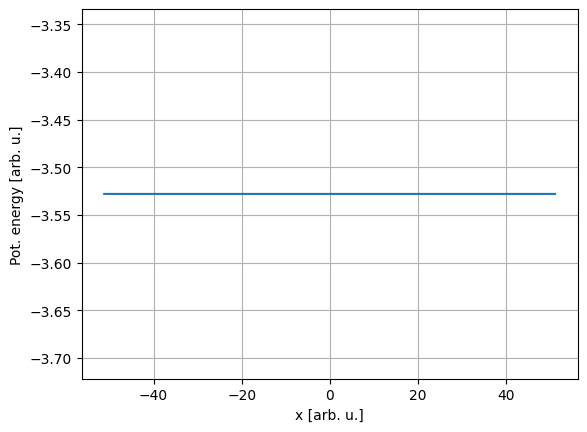

In [16]:
import matplotlib.pyplot as plt
import potentials as pots
import pint

ureg = unit_sys.ureg

#Standard electrode lists
#https://chem.libretexts.org/Ancillary_Materials/Reference/Reference_Tables/Electrochemistry_Tables/P1%3A_Standard_Reduction_Potentials_by_Element
#https://www.engineeringtoolbox.com/electrode-potential-d_482.html
#https://en.wikipedia.org/wiki/Standard_electrode_potential_(data_page)
#https://nano3dsystems.com/wp-content/uploads/2019/06/Ir.pdf
standard_potential_of_Au_in_V=1.83*ureg.volt #http://hyperphysics.phy-astr.gsu.edu/hbase/Tables/electpot.html
standard_potential_of_Al_in_V=-1.66*ureg.volt 
standard_potential_of_Ir_in_V=0.87*ureg.volt #standard_potential_of_Ir_in_V=0.87 #10.1002/elan.200403200
standard_potential_of_O3_in_V=1.246*ureg.volt # standard_potential_of_O3_in_V=1.246 #https://www.chm.uri.edu/weuler/chm112/refmater/redpottable.html

wall_in_V = standard_potential_of_Al_in_V-standard_potential_of_Au_in_V
wall_in_eV = (wall_in_V*ureg("elementary_charge").to("C")).to("eV")
wall_in_unit_sys = (wall_in_eV/unit_sys.energy_unit.to("eV")).magnitude
print(wall_in_eV,unit_sys.energy_unit.to("eV"))
print(wall_in_unit_sys)

well_in_V = standard_potential_of_Au_in_V-standard_potential_of_Ir_in_V
well_in_eV = (well_in_V*ureg("elementary_charge").to("C")).to("eV")
well_in_unit_sys = (well_in_eV/unit_sys.energy_unit.to("eV")).magnitude
print(well_in_eV,unit_sys.energy_unit.to("eV"))
print(well_in_unit_sys)

energy_unit_in_ev = unit_sys.energy_unit.to('eV').magnitude
print(energy_unit_in_ev)
length_unit_in_nm = unit_sys.length_unit.to('nm').magnitude


wall_width = (10 * unit_sys.ureg("bohr").to("m") / unit_sys.length_unit).magnitude
print(wall_width)
well_width = 800/length_unit_in_nm
print(well_width)

modelpot=pots.SmoothStackPotential(uxgrid,wallwidth=wall_width,\
                                   wallheight=wall_in_unit_sys,\
                                   welldepth=well_in_unit_sys,\
                                   wellwidth=well_width,\
                                   wallrise = 2,\
                                   wellfall = 2)
#modelpot=StackPotential(uxgrid)

plt.plot(uxgrid,modelpot(0))
plt.xlabel("x [arb. u.]")
plt.ylabel("Pot. energy [arb. u.]")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.grid()
plt.show()

/usr/local/lib/python3.10/dist-packages/matplotlib/cbook.py:1345: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


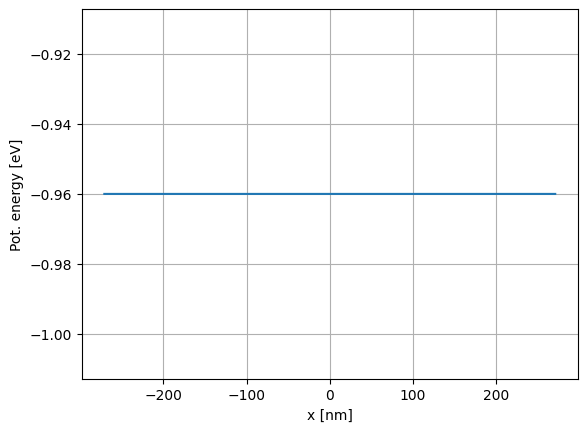

In [17]:
x = uxgrid * unit_sys.length_unit.to('nm')
y = modelpot(0) * unit_sys.energy_unit.to('eV')

plt.plot(x, y)
plt.xlabel("x [nm]")
plt.ylabel("Pot. energy [eV]")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.grid()
plt.show()

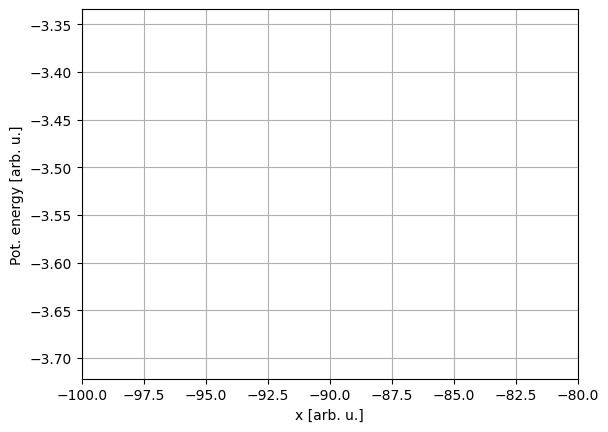

In [18]:
plt.plot(uxgrid,modelpot(0))
plt.xlabel("x [arb. u.]")
plt.ylabel("Pot. energy [arb. u.]")
plt.xlim([-100, -80])
plt.grid()
plt.show()

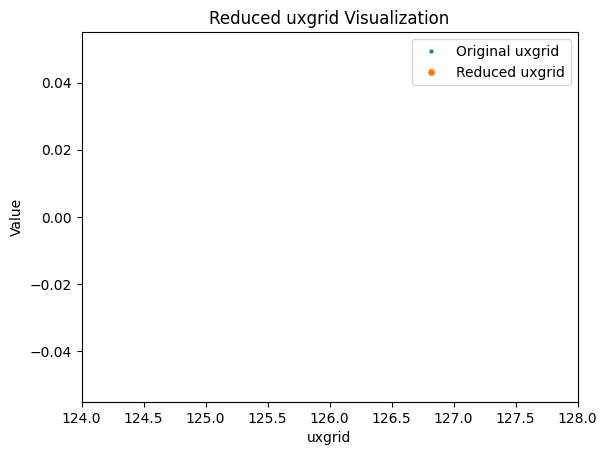

Original uxgrid length: 4096
Reduced uxgrid length: 1024


In [19]:
# Desired number of points
desired_points = 1024

# Calculate the step size to reduce the number of points
step_size = uxgrid_num // desired_points

# Create the mask
mask = np.zeros(uxgrid_num, dtype=bool)
mask[::step_size] = True

# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=2, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=4, label='Reduced uxgrid')
plt.xlim([124, 128])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

In [20]:
# Highlighted ranges
highlight_ranges = [(-122, -118), (118, 122)]

# Initialize mask
mask_highlight_ranges = np.zeros(uxgrid_num, dtype=bool)

# Apply mask for highlighted ranges
for start, end in highlight_ranges:
    mask_highlight_ranges |= (uxgrid >= start) & (uxgrid <= end)

# Number of highlighted points
highlighted_num = np.sum(mask_highlight_ranges)

print(f"Number of uxgrid points: {uxgrid_num}")
print(f"Number of highlighted points: {highlighted_num}")

Number of uxgrid points: 4096
Number of highlighted points: 0


In [21]:
mask += mask_highlight_ranges

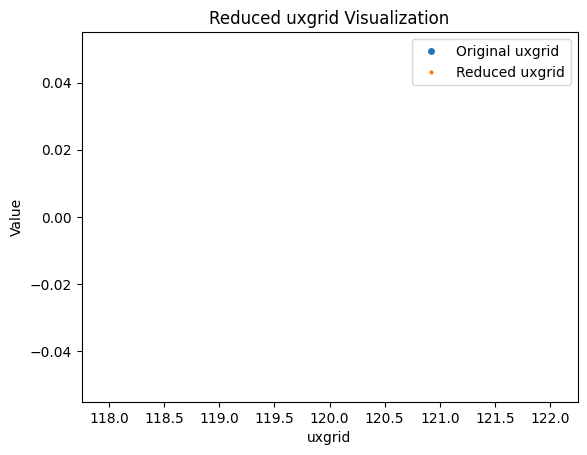

Original uxgrid length: 4096
Reduced uxgrid length: 1024


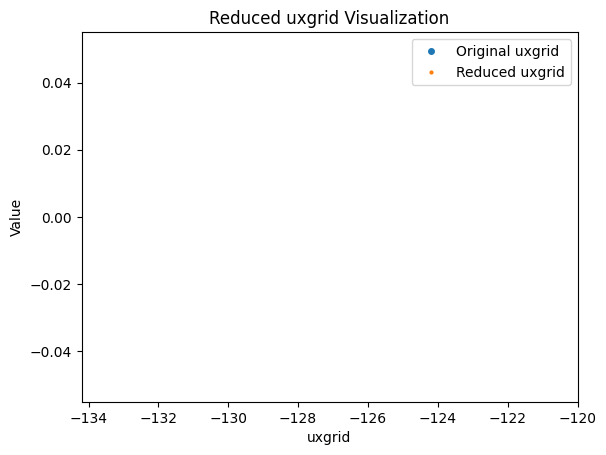

Original uxgrid length: 4096
Reduced uxgrid length: 1024


In [22]:
# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=4, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=2, label='Reduced uxgrid')
plt.xlim([highlight_ranges[1][0]-10*uxgrid_dx, highlight_ranges[1][1]+10*uxgrid_dx])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=4, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=2, label='Reduced uxgrid')
plt.xlim([1.1*highlight_ranges[0][0], highlight_ranges[0][0]+2])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

# Compute eigen states

In [23]:
#zeropot=quat.ZeroPotential(uxgrid)
zeropot=pots.ZeroPotential(uxgrid)
constpot=pots.ConstantPotential(uxgrid, 1.0)

ham_static = quat.HamiltonOperator(uxgrid,hbar=unit_sys.hb,\
                                   me=unit_sys.me,\
                                   charge=unit_sys.e0,\
                                   scalarpot=modelpot, vectorpot=zeropot )

In [24]:
import scipy.sparse as sparse

mat=ham_static(0)
eigenvalues, eigenvectors = sparse.linalg.eigsh(mat, 20,which = 'SR')

print(eigenvalues[0])

-3.5279302249613713


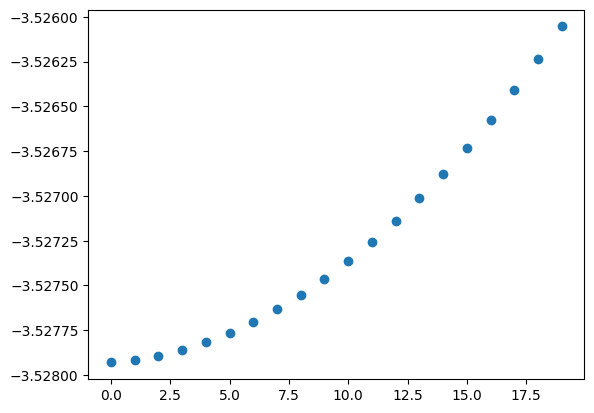

In [25]:
plt.scatter(np.arange(20),eigenvalues)

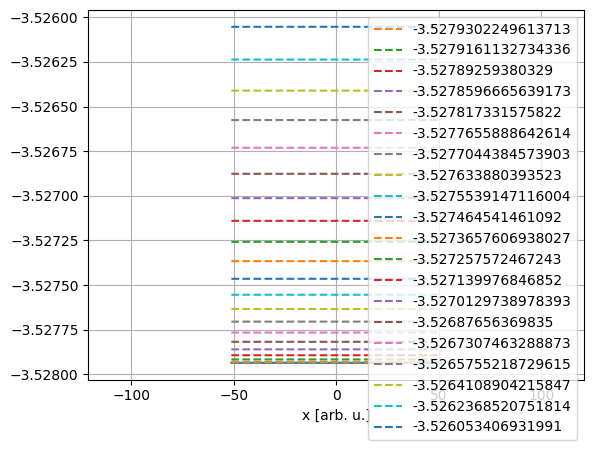

In [26]:
# plt.plot(uxgrid,modelpot(0),label="Pot")
# plt.plot(uxgrid,np.real(eigenvectors[:,0]),label="Re")
# plt.plot(uxgrid,np.imag(eigenvectors[:,0]),label="Im")
# plt.plot(uxgrid,np.abs(eigenvectors[:,0]),label="Abs")

plt.plot(uxgrid,modelpot(0))
for eval,evec  in zip(eigenvalues,np.transpose(eigenvectors)):
    plt.plot(uxgrid,eval*np.ones_like(uxgrid),"--",label=str(eval))
    #plt.plot(uxgrid,0.5*np.real(evec)+eval)#,label="Re")
    #plt.plot(uxgrid,0.5*np.imag(evec)+eval)#,label="Im")
    #plt.plot(uxgrid,np.abs(evec)**2+eval)#,label="Abs")
plt.xlabel("x [arb. u.]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend(loc='upper right')
plt.grid()
plt.show()

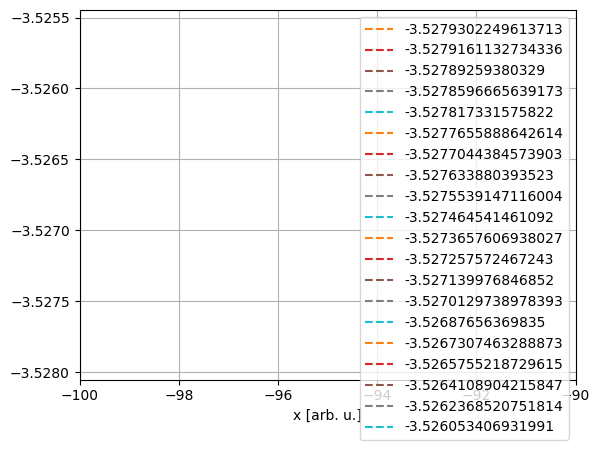

In [27]:
plt.plot(uxgrid,modelpot(0))
for eval,evec  in zip(eigenvalues,np.transpose(eigenvectors)):
    plt.plot(uxgrid,eval*np.ones_like(uxgrid),"--",label=str(eval))
    #plt.plot(uxgrid,0.5*np.real(evec)+eval)#,label="Re")
    #plt.plot(uxgrid,0.5*np.imag(evec)+eval)#,label="Im")
    plt.plot(uxgrid,np.abs(evec)**2+eval)#,label="Abs")
plt.xlabel("x [arb. u.]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
#plt.ylim(-520000,-480000)
plt.xlim(-100,-90)
plt.legend(loc='upper right')
plt.grid()
plt.show()

In [28]:
import quantum_transport_toolkit as trat

ein=(1.0*unit_sys.ureg("eV") / unit_sys.energy_unit.to("eV")).magnitude #0.2
print(ein)
kin=dispersion.energy2k(ein)
print(kin)

qppk, qpmk = trat.quasiparticles_at_given_energy(ein,kin,ham_static,normed=True)
#qp_pk_hus_normed, qp_mk_hus_normed = trat.quasiparticles_at_given_energy(ein,kin,ham_static,normed=True)

3.674932217565435
27.658344336980527
0.004420756514396525 0.0011873419178770738


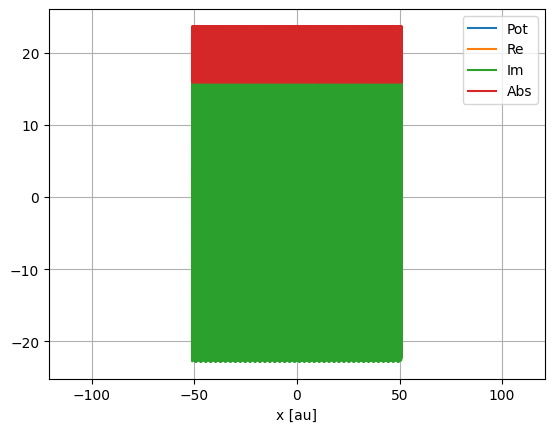

In [29]:
plt.plot(uxgrid,modelpot(0),label="Pot")
plt.plot(uxgrid,np.real(qppk["state"]["value"]),label="Re")
plt.plot(uxgrid,np.imag(qppk["state"]["value"]),label="Im")
plt.plot(uxgrid,np.abs(qppk["state"]["value"]),label="Abs")
plt.xlabel("x [au]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.grid()
plt.show()

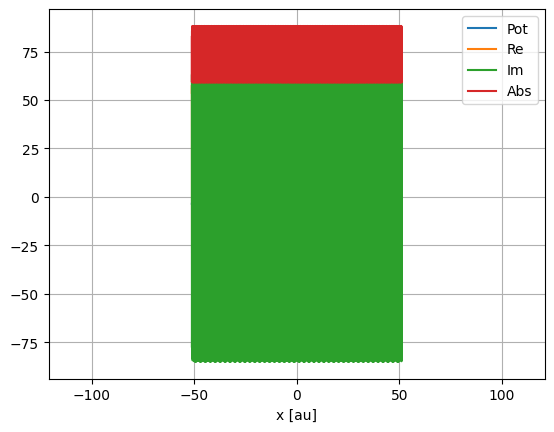

In [30]:
plt.plot(uxgrid,modelpot(0),label="Pot")
plt.plot(uxgrid,np.real(qpmk["state"]["value"]),label="Re")
plt.plot(uxgrid,np.imag(qpmk["state"]["value"]),label="Im")
plt.plot(uxgrid,np.abs(qpmk["state"]["value"]),label="Abs")
plt.xlabel("x [au]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.grid()
plt.show()

# Laser potential

In [31]:
t_start=0
t_stop=200.0
#t_num=10000

#utgrid=np.linspace(t_start,t_stop,t_num)
#utgrid_dt=utgrid[1]-utgrid[0]
utgrid_dt=0.05
utgrid=np.arange(t_start,t_stop,utgrid_dt)
t_num=len(utgrid)

#print(utgrid_dt)
print(t_num)

4000


In [32]:
spot_size = (800*unit_sys.ureg("nm") / unit_sys.length_unit.to("nm")).magnitude
print(spot_size)

magnitude_of_electric_field = (1.0e6*unit_sys.ureg("V/m") / unit_sys.electric_field_unit.to("V/m")).magnitude
print(magnitude_of_electric_field)

laserpot_cep0 = pots.SmoothLaserPotential(uxgrid,\
                                    spatial_min = -0.5*spot_size,\
                                    spatial_max = 0.5*spot_size,beta=0.25)

#laserpot_cep0 = LaserPotential(uxgrid)

151.17808996978238
0.019446903811524464


In [33]:
# X,Y = np.meshgrid(uxgrid,utgrid)

# Z=laserpot_cep0(Y)

# z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
# pcm = plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
# plt.colorbar(pcm)
 
# plt.title('External LASER field', fontweight ="bold")
# plt.ylim(laserpot_cep0.temporal_min,1.2*laserpot_cep0.temporal_max)
# #plt.xlim(2*laserpot_cep0.spatial_min,2*laserpot_cep0.spatial_max)
# plt.xlabel("x [arb. u.]")
# plt.ylabel("time [arb. u.]")
# plt.show()

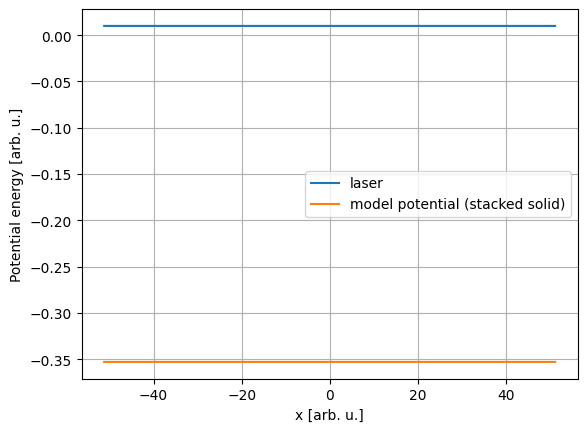

In [34]:
plt.plot(uxgrid, laserpot_cep0(laserpot_cep0.temporal_width/2),label="laser")
plt.plot(uxgrid, 0.1*modelpot(uxgrid),label="model potential (stacked solid)")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.xlabel("x [arb. u.]")
plt.ylabel("Potential energy [arb. u.]")
plt.grid()
plt.show()

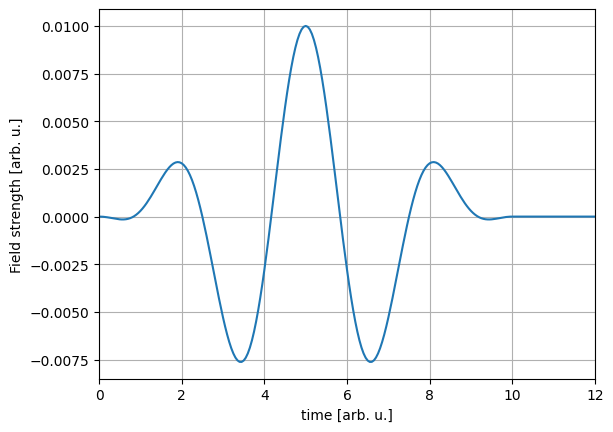

In [35]:
plt.plot(utgrid, laserpot_cep0.value_at(0.0,utgrid),label="laser")
plt.xlabel("time [arb. u.]")
plt.ylabel("Field strength [arb. u.]")
plt.xlim(0,1.2*laserpot_cep0.temporal_width)
plt.grid()
plt.show()

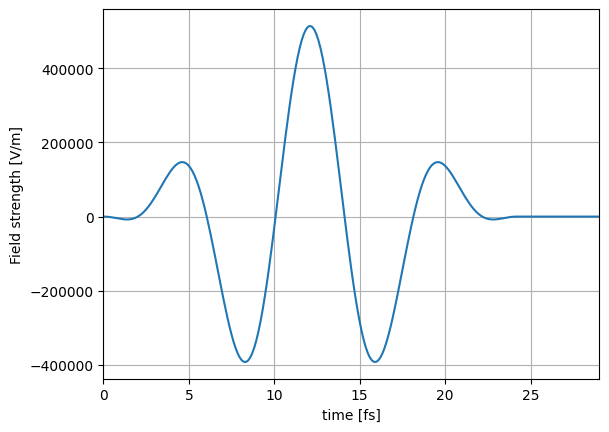

In [36]:
x = utgrid * unit_sys.time_unit.to('fs')
y = laserpot_cep0.value_at(0.0,utgrid) * unit_sys.electric_field_unit.to('V/m')

plt.plot(x, y,label="laser")
plt.xlabel("time [fs]")
plt.ylabel("Field strength [V/m]")
plt.xlim(0,1.2*laserpot_cep0.temporal_width*unit_sys.time_unit.to('fs').magnitude)
plt.grid()
plt.show()

# Vcap check

In [37]:
nx=len(uxgrid)
nt=len(utgrid)

## Advanced methode

In [38]:
import quantum_transport_toolkit as trat

ein=(1.0*unit_sys.ureg("eV") / unit_sys.energy_unit.to("eV")).magnitude #0.2
print(ein)
kin=dispersion.energy2k(ein)

qppk, qpmk = trat.quasiparticles_at_given_energy(ein,kin,ham_static)

3.674932217565435
0.004420756514396525 0.0011873419178770738


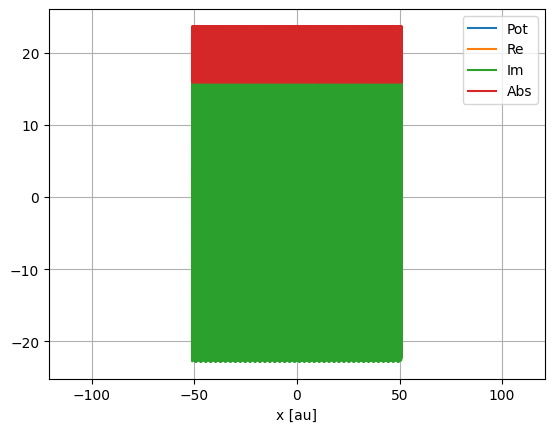

In [39]:
plt.plot(uxgrid,modelpot(0),label="Pot")
plt.plot(uxgrid,np.real(qppk["state"]["value"]),label="Re")
plt.plot(uxgrid,np.imag(qppk["state"]["value"]),label="Im")
plt.plot(uxgrid,np.abs(qppk["state"]["value"]),label="Abs")
plt.xlabel("x [au]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.grid()
plt.show()

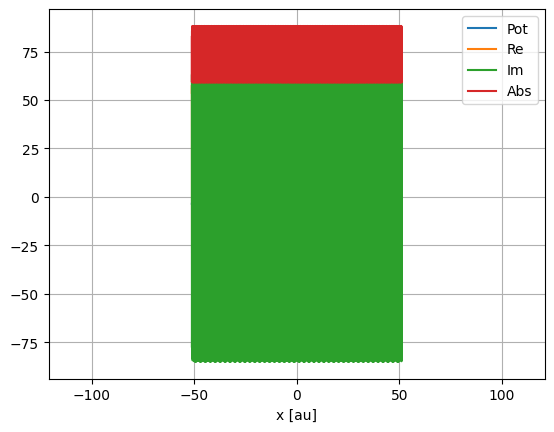

In [40]:
plt.plot(uxgrid,modelpot(0),label="Pot")
plt.plot(uxgrid,np.real(qpmk["state"]["value"]),label="Re")
plt.plot(uxgrid,np.imag(qpmk["state"]["value"]),label="Im")
plt.plot(uxgrid,np.abs(qpmk["state"]["value"]),label="Abs")
plt.xlabel("x [au]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.grid()
plt.show()

In [41]:
v_cap=quat.vcap_generator(uxgrid,param_x0=180,param_lambda0 = 0.05)

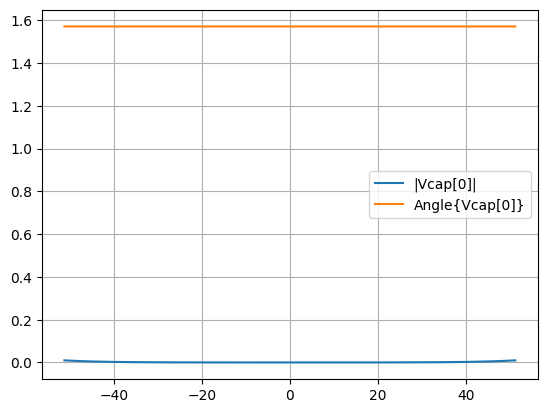

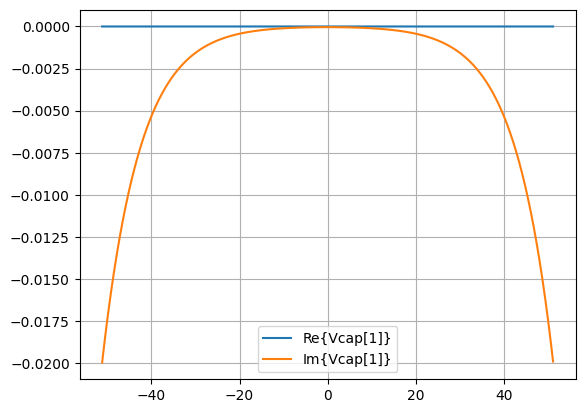

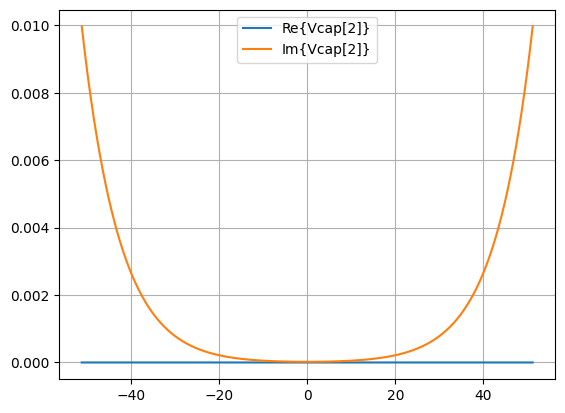

In [42]:
plt.plot(uxgrid,np.abs(v_cap[0]),label="|Vcap[0]|")
plt.plot(uxgrid,np.angle(v_cap[0]),label="Angle{Vcap[0]}")
plt.legend()
plt.grid()
plt.show()

plt.plot(uxgrid,np.real(v_cap[1]),label="Re{Vcap[1]}")
plt.plot(uxgrid,np.imag(v_cap[1]),label="Im{Vcap[1]}")
plt.legend()
plt.grid()
plt.show()

plt.plot(uxgrid,np.real(v_cap[2]),label="Re{Vcap[2]}")
plt.plot(uxgrid,np.imag(v_cap[2]),label="Im{Vcap[2]}")
plt.legend()
plt.grid()
plt.show()

In [43]:
psi_pk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qppk["energy"]/unit_sys.hb,\
        psi0_initial = qppk["state"],\
        scalarpot = modelpot,\
        vectorpot=laserpot_cep0,\
        dt=utgrid_dt, t_start=t_start, t_stop=t_stop)#,
        #vcap=v_cap)

psi_mk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qpmk["energy"]/unit_sys.hb,\
        psi0_initial = qpmk["state"],\
        scalarpot = modelpot,\
        vectorpot=laserpot_cep0,\
        dt=utgrid_dt, t_start=t_start, t_stop=t_stop)#,
        #vcap=v_cap)

In [44]:
psi_pk_te.run()

In [45]:
psi_mk_te.run()

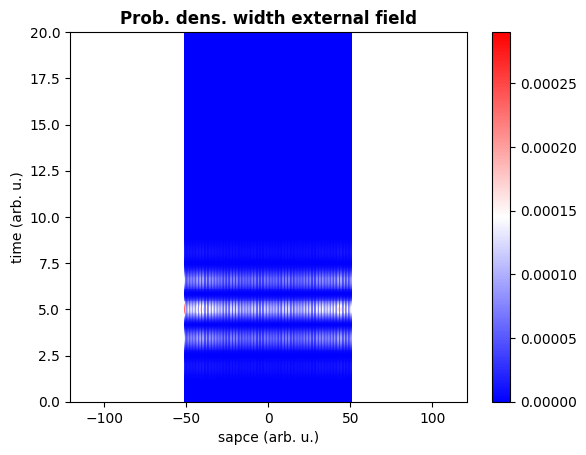

In [46]:
X,Y = np.meshgrid(uxgrid,utgrid)

Z=np.transpose(quat.probability_density(psi_pk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.ylim(0,2*laserpot_cep0.temporal_width)
plt.show()

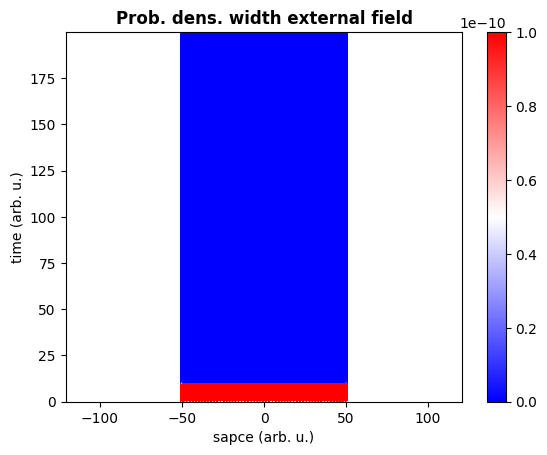

In [47]:
X,Y = np.meshgrid(uxgrid,utgrid)

Z=np.transpose(quat.probability_density(psi_pk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr',vmax=1e-10) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)

plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
#plt.ylim(2*laserpot_cep0.temporal_width,1200)
plt.show()

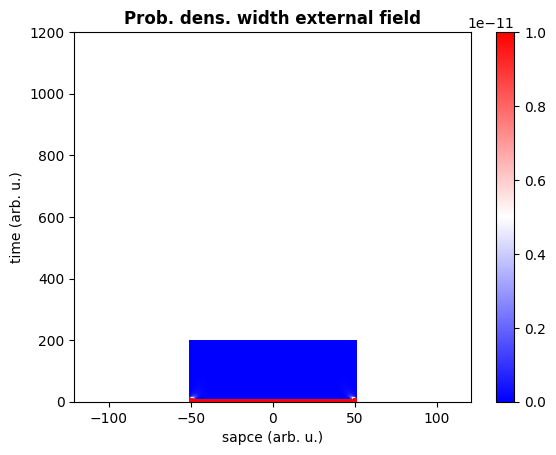

In [48]:
X,Y = np.meshgrid(uxgrid,utgrid)

Z=np.transpose(quat.probability_density(psi_mk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr',vmax=1e-11) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.ylim(0,1200)#2*laserpot_cep0.temporal_width)
plt.show()

# Compare with masked

In [49]:
masked_psi_pk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qppk["energy"]/quat.hartree_atomic_units.hb,\
        psi0_initial = qppk["state"],\
        scalarpot = modelpot,\
        vectorpot=laserpot_cep0,\
        dt=utgrid_dt, t_start=t_start, t_stop=t_stop,\
        vcap=v_cap, mask=mask)

masked_psi_mk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qpmk["energy"]/quat.hartree_atomic_units.hb,\
        psi0_initial = qpmk["state"],\
        scalarpot = modelpot,\
        vectorpot=laserpot_cep0,\
        dt=utgrid_dt, t_start=t_start, t_stop=t_stop,\
        vcap=v_cap, mask=mask)

In [50]:
masked_psi_pk_te.run()

In [51]:
masked_psi_mk_te.run()

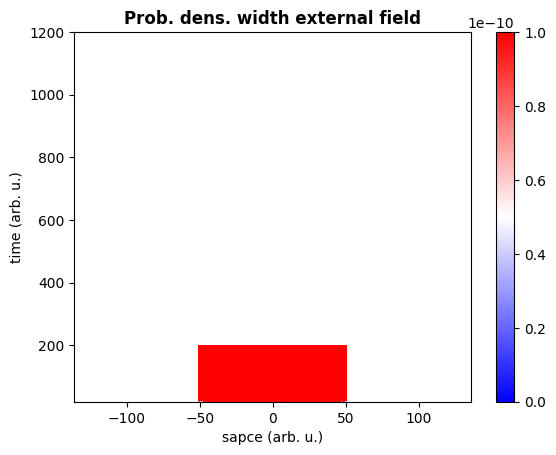

In [52]:
X,Y = np.meshgrid(uxgrid[mask],utgrid)

Z=np.transpose(quat.probability_density(masked_psi_pk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr',vmax=1e-10) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)

plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.9*modelpot.wellwidth, 0.9*modelpot.wellwidth])
plt.ylim(2*laserpot_cep0.temporal_width,1200)
plt.show()

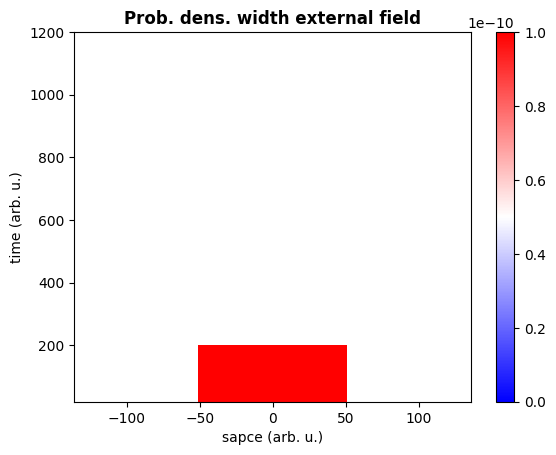

In [53]:
X,Y = np.meshgrid(uxgrid[mask],utgrid)

Z=np.transpose(quat.probability_density(masked_psi_mk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr',vmax=1e-10) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.9*modelpot.wellwidth, 0.9*modelpot.wellwidth])
plt.ylim(2*laserpot_cep0.temporal_width,1200)#2*laserpot_cep0.temporal_width)
plt.show()

# Compute probability current

In [54]:
# choose masurement points on the right and the left side
meas_point_right=110
meas_point_left=-meas_point_right

In [55]:


left_index = np.abs(np.array(uxgrid) - meas_point_left).argmin()#1300
right_index = np.abs(np.array(uxgrid) - meas_point_right).argmin()#
x_left = uxgrid[left_index]
x_right = uxgrid[right_index]

print(left_index,right_index)
print(x_left,x_right)

0 4095
-51.2 51.17499999999417


In [56]:
pc2_pk=quat.probability_current(psi_pk_te.psi_time_evolution)
pc2_mk=quat.probability_current(psi_mk_te.psi_time_evolution)

pc2_sum=pc2_pk+pc2_mk

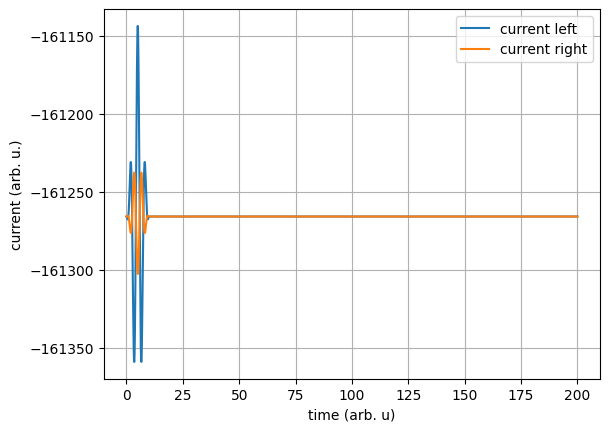

In [57]:
pc_sum_left=pc2_sum[left_index,:]
pc_sum_right=pc2_sum[right_index,:]
#pcsum_diff=pcsum_right-pcsum_left

plt.plot(utgrid, pc_sum_left,label="current left")
plt.plot(utgrid, pc_sum_right,label="current right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

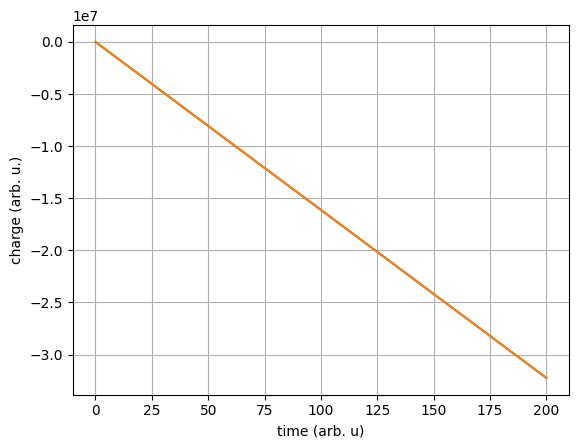

In [58]:
from scipy import integrate

charge_left = integrate.cumtrapz(pc_sum_left, utgrid, initial=0)
charge_right = integrate.cumtrapz(pc_sum_right, utgrid, initial=0)
#charge_diff = integrate.cumtrapz(pcsum_diff, utgrid, initial=0)

plt.plot(utgrid, charge_left,label="charge left")
plt.plot(utgrid, charge_right,label="charge right")
#plt.plot(utgrid, charge_left+charge_right)
#plt.plot(utgrid, charge_diff)
plt.xlabel("time (arb. u)")
plt.ylabel("charge (arb. u.)")
#plt.xlim(100)
#plt.ylim(-1e-3,1e-3)
plt.grid()
plt.show()

# compare with masked grid results

In [59]:
masked_pc2_pk=quat.probability_current(masked_psi_pk_te.psi_time_evolution)
masked_pc2_mk=quat.probability_current(masked_psi_mk_te.psi_time_evolution)

masked_pc2_sum=masked_pc2_pk+masked_pc2_mk

In [60]:
masked_left_index = np.abs(np.array(reduced_uxgrid) - meas_point_left).argmin()#1300
masked_right_index = np.abs(np.array(reduced_uxgrid) - meas_point_right).argmin()#
masked_x_left = reduced_uxgrid[masked_left_index]
masked_x_right = reduced_uxgrid[masked_right_index]

print(masked_x_left,masked_x_right)

-51.2 51.09999999999418


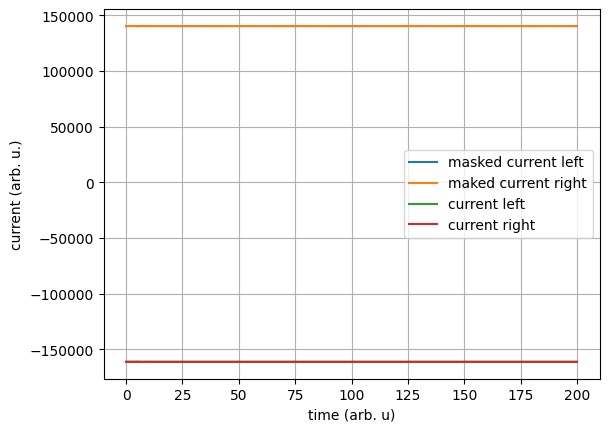

In [61]:
masked_pc_sum_left=masked_pc2_sum[masked_left_index,:]
masked_pc_sum_right=masked_pc2_sum[masked_right_index,:]
#pcsum_diff=pcsum_right-pcsum_left

plt.plot(utgrid, masked_pc_sum_left,label="masked current left")
plt.plot(utgrid, masked_pc_sum_right,label="maked current right")
plt.plot(utgrid, pc_sum_left,label="current left")
plt.plot(utgrid, pc_sum_right,label="current right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

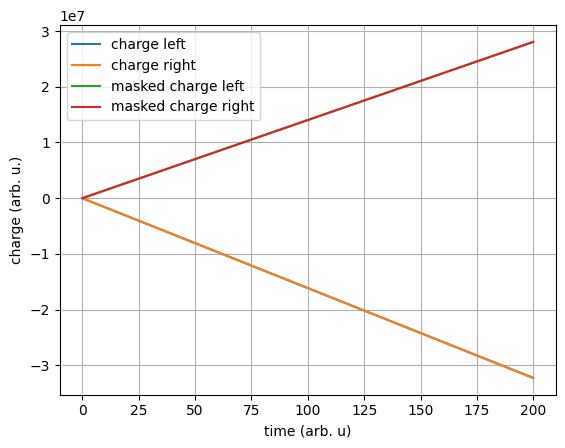

In [62]:
from scipy import integrate

masked_charge_left = integrate.cumtrapz(masked_pc_sum_left, utgrid, initial=0)
masked_charge_right = integrate.cumtrapz(masked_pc_sum_right, utgrid, initial=0)
#charge_diff = integrate.cumtrapz(pcsum_diff, utgrid, initial=0)

plt.plot(utgrid, charge_left,label="charge left")
plt.plot(utgrid, charge_right,label="charge right")
plt.plot(utgrid, masked_charge_left,label="masked charge left")
plt.plot(utgrid, masked_charge_right,label="masked charge right")
plt.xlabel("time (arb. u)")
plt.ylabel("charge (arb. u.)")
#plt.xlim(100)
#plt.ylim(-1e-3,1e-3)
plt.legend()
plt.grid()
plt.show()